# Inverse Heat Transfer with Automatic Differentiation

A steel plate is heating up. You have thermocouple readings at a handful of
locations, but you don't know the exact material properties — or even what the
temperature distribution looked like before heating started. Can you figure it out?

This notebook solves two inverse problems of increasing ambition. The forward
model is a 2D transient heat-conduction solver written in plain **Fortran**, whose
exact derivatives are generated automatically by [Enzyme](https://enzyme.mit.edu/)
at the LLVM IR level — no manual adjoint code, no source modifications. Wrapped as
a [Tesseract](https://github.com/pasteurlabs/tesseract-core) and bridged into JAX
with [`tesseract-jax`](https://github.com/pasteurlabs/tesseract-jax), the Fortran
solver becomes an ordinary differentiable JAX function, so `jax.grad` flows
straight through it.

1. **Part 1: Scalar calibration** — recover 2 material parameters (k₀, k₁) from 9 sensors
2. **Part 2: Thermal forensics** — recover the full 900-element initial temperature
   field from 100 sensors (finite differences would need 901 forward solves per
   iteration; one reverse-mode pass gives all 900 gradients at once)

The optimizers below only ever see a JAX function. They never know the gradients
came from a compiled Fortran solver differentiated by an LLVM pass.

## Build and serve the Enzyme AD Tesseract

The build compiles the Fortran source to LLVM IR with LFortran, runs the Enzyme
AD pass to synthesize forward- and reverse-mode derivatives, and links everything
into a shared library — all inside the container. This step downloads the LLVM 19
toolchain and builds Enzyme from source, so the first build takes a few minutes.

In [1]:
%%bash
tesseract build .

 [i] Building image ...
⠸ Processing
 [i] Built image sha256:33ec38a694cd, ['enzyme-thermal-2d:1.0.0', 'enzyme-thermal-2d:latest']


["enzyme-thermal-2d:1.0.0", "enzyme-thermal-2d:latest"]


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tesseract_jax import apply_tesseract

from tesseract_core import Tesseract

# JAX needs float64 to match the Fortran solver's double precision.
jax.config.update("jax_enable_x64", True)

# Serve the Tesseract; it stays alive for the rest of the notebook.
enzyme_tess = Tesseract.from_image("enzyme-thermal-2d")
enzyme_tess.serve()

In [3]:
# Grid and simulation parameters (fixed throughout)
nx, ny = 30, 30
n = nx * ny
n_steps = 500
dt = 0.05  # 500 steps x 0.05s = 25s (CFL-safe up to k0 ~ 80)
Lx, Ly = 0.1, 0.05

# Fixed physical parameters
rho = 7850.0  # density [kg/m^3] (mild steel)
cp = 460.0  # specific heat [J/(kg*K)]
h_conv = 25.0  # convection coefficient [W/(m^2*K)]
T_inf = 293.15  # ambient temperature [K]
T_hot = 373.15  # hot wall temperature [K]

# Initial condition: uniform ambient temperature
T_init = np.full(n, T_inf)
Q = np.zeros(n)  # no internal heating

print(f"Simulation: {n_steps} steps x {dt}s = {n_steps * dt:.0f}s total")

Simulation: 500 steps x 0.05s = 25s total


## Part 1: Scalar calibration (2 parameters)

### Generate synthetic data

We run the solver with the **true** material properties to produce a ground-truth
temperature field, then sample it at sparse sensor locations with added noise.
In practice, these would be thermocouple readings from a real component.

Because the solver is now a JAX function, we build its inputs as JAX arrays. The
static grid sizes (`nx`, `ny`, `n_steps`) stay as plain integers; everything
differentiable is a JAX array.

In [4]:
# True material properties (what we want to recover)
k0_true = 45.0  # base conductivity [W/(m*K)]
k1_true = -0.02  # temperature coefficient [W/(m*K^2)]


def make_inputs(k0, k1):
    """Build a full input dict (JAX arrays) for the Tesseract."""
    return {
        "T_init": jnp.asarray(T_init),
        "Q": jnp.asarray(Q),
        "nx": nx,
        "ny": ny,
        "n_steps": n_steps,
        "k0": jnp.asarray(k0, dtype=jnp.float64),
        "k1": jnp.asarray(k1, dtype=jnp.float64),
        "rho": jnp.float64(rho),
        "cp": jnp.float64(cp),
        "h_conv": jnp.float64(h_conv),
        "T_inf": jnp.float64(T_inf),
        "T_hot": jnp.float64(T_hot),
        "Lx": jnp.float64(Lx),
        "Ly": jnp.float64(Ly),
        "dt": jnp.float64(dt),
    }


def solve(k0, k1):
    """Forward solve through the Fortran solver, returns T_final as a JAX array."""
    return apply_tesseract(enzyme_tess, make_inputs(k0, k1))["T_final"]


# Run the ground-truth simulation
T_true = np.asarray(solve(k0_true, k1_true)).reshape(ny, nx)

print(f"Ground truth: k0={k0_true}, k1={k1_true}")
print(f"Temperature range: {T_true.min():.2f} K to {T_true.max():.2f} K")

Ground truth: k0=45.0, k1=-0.02
Temperature range: 297.61 K to 373.15 K


In [5]:
# Place sensors on a regular grid in the interior (away from BCs)
# This mimics a realistic thermocouple layout
sensor_ix = [7, 15, 22]  # x positions
sensor_jy = [7, 15, 22]  # y positions
sensor_indices = []
sensor_coords = []

for jy in sensor_jy:
    for ix in sensor_ix:
        sensor_indices.append(jy * nx + ix)
        sensor_coords.append((ix, jy))

sensor_indices = np.array(sensor_indices)
n_sensors = len(sensor_indices)

# Extract true temperatures at sensor locations and add noise
rng = np.random.default_rng(42)
noise_std = 0.5  # K — realistic thermocouple noise
T_true_flat = T_true.flatten()
T_obs = T_true_flat[sensor_indices] + rng.normal(0, noise_std, n_sensors)

print(f"Number of sensors: {n_sensors}")
print(f"Noise std: {noise_std} K")
print(f"Observed temperatures: {T_obs.round(2)}")

Number of sensors: 9
Noise std: 0.5 K
Observed temperatures: [341.04 340.36 341.26 314.51 313.06 313.39 301.68 301.46 301.61]


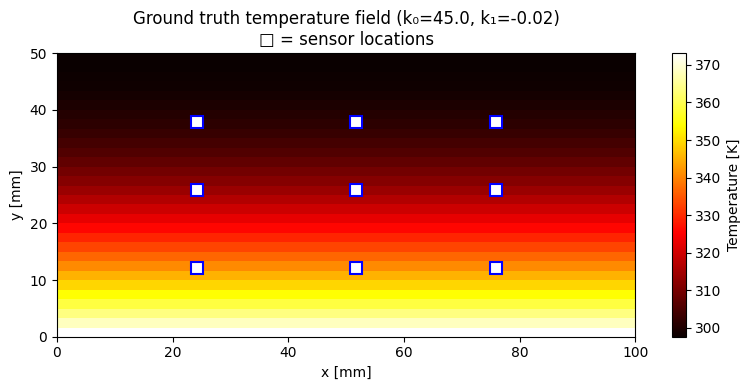

In [6]:
# Visualize the ground truth and sensor locations
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
im = ax.imshow(
    T_true, origin="lower", cmap="hot", extent=[0, Lx * 1e3, 0, Ly * 1e3], aspect="auto"
)
plt.colorbar(im, ax=ax, label="Temperature [K]")

# Plot sensor locations
for ix, jy in sensor_coords:
    x_mm = ix / (nx - 1) * Lx * 1e3
    y_mm = jy / (ny - 1) * Ly * 1e3
    ax.plot(x_mm, y_mm, "ws", markersize=8, markeredgecolor="blue", markeredgewidth=1.5)

ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title(
    f"Ground truth temperature field (k₀={k0_true}, k₁={k1_true})\n□ = sensor locations"
)
plt.tight_layout()
plt.show()

### Define the inverse problem

Minimize the misfit between predicted and observed sensor temperatures:

$$
J(k_0, k_1) = \frac{1}{2} \sum_{i=1}^{N_\text{sensors}} \left( T_\text{pred}(\mathbf{x}_i; k_0, k_1) - T_\text{obs}(\mathbf{x}_i) \right)^2
$$

`loss_fn` is a plain JAX function that happens to call the Fortran solver through
`apply_tesseract`. We hand it to `jax.value_and_grad`, and JAX propagates the
cotangent through the HTTP boundary into Enzyme's reverse-mode pass — one reverse
sweep returns $\partial J / \partial k_0$ and $\partial J / \partial k_1$ at once.
Finite differences would need a separate forward solve per parameter.

In [7]:
T_obs_jax = jnp.asarray(T_obs)


def loss_fn(params):
    """Sensor-misfit loss as a function of [k0, k1]. Pure JAX."""
    k0, k1 = params
    T_pred = solve(k0, k1)
    residuals = T_pred[sensor_indices] - T_obs_jax
    return 0.5 * jnp.sum(residuals**2)


# jax.value_and_grad differentiates straight through the Fortran solver.
value_and_grad = jax.value_and_grad(loss_fn)

# Sanity check: gradient at the initial guess.
loss0, grad0 = value_and_grad(jnp.array([60.0, 0.01]))
print(f"Initial loss = {loss0:.4f}")
print(f"Gradient via Enzyme: dJ/dk0 = {grad0[0]:.6f}, dJ/dk1 = {grad0[1]:.6f}")

Initial loss = 409.1875
Gradient via Enzyme: dJ/dk0 = 27.526953, dJ/dk1 = 9510.217207


### Run the optimization

We start from a deliberately wrong initial guess (33% off on k₀, wrong sign on k₁)
and let `scipy.optimize.minimize` drive L-BFGS-B, with `jax.value_and_grad`
supplying both the loss and its gradient. The bounds keep the parameters physically
plausible and the time stepping CFL-safe.

In [8]:
from scipy.optimize import minimize

# Initial guess: 33% off on k0, wrong sign on k1
x0 = np.array([60.0, 0.01])

# Track optimization history
history = {"k0": [x0[0]], "k1": [x0[1]], "loss": []}


def scipy_objective(params):
    loss, grad = value_and_grad(jnp.asarray(params))
    return float(loss), np.asarray(grad, dtype=np.float64)


def callback(params):
    loss, _ = scipy_objective(params)
    history["k0"].append(params[0])
    history["k1"].append(params[1])
    history["loss"].append(loss)
    print(f"  k0={params[0]:.4f}, k1={params[1]:.6f}, loss={loss:.6f}")


history["loss"].append(scipy_objective(x0)[0])
print(f"Initial guess: k0={x0[0]:.2f}, k1={x0[1]:.4f}, loss={history['loss'][0]:.4f}")

result = minimize(
    fun=scipy_objective,
    x0=x0,
    method="L-BFGS-B",
    jac=True,  # scipy_objective returns (loss, grad)
    bounds=[(5.0, 80.0), (-0.08, 0.08)],  # stay CFL-safe
    callback=callback,
    options={"maxiter": 50, "ftol": 1e-12, "gtol": 1e-8},
)

k0_opt, k1_opt = result.x
T_opt = np.asarray(solve(k0_opt, k1_opt)).reshape(ny, nx)

print(f"\nOptimization finished in {result.nit} iterations")
print(f"  True:      k0={k0_true:.4f}, k1={k1_true:.6f}")
print(f"  Recovered: k0={k0_opt:.4f}, k1={k1_opt:.6f}")
print(
    f"  Error:     k0: {abs(k0_opt - k0_true) / k0_true * 100:.2f}%, "
    f"k1: {abs(k1_opt - k1_true) / abs(k1_true) * 100:.2f}%"
)

Initial guess: k0=60.00, k1=0.0100, loss=409.1875
  k0=49.5370, k1=-0.024209, loss=10.623775
  k0=46.9414, k1=-0.032678, loss=4.835226
  k0=48.0019, k1=-0.029202, loss=0.989078
  k0=47.9192, k1=-0.029457, loss=0.961049
  k0=47.9118, k1=-0.029464, loss=0.960913
  k0=47.9059, k1=-0.029456, loss=0.960832
  k0=47.8638, k1=-0.029372, loss=0.960316
  k0=47.7726, k1=-0.029154, loss=0.959282
  k0=47.5080, k1=-0.028466, loss=0.956421
  k0=46.8954, k1=-0.026791, loss=0.950077
  k0=45.6409, k1=-0.023246, loss=0.937793
  k0=43.9279, k1=-0.018262, loss=0.922245
  k0=42.8393, k1=-0.014951, loss=0.912410
  k0=42.8101, k1=-0.014745, loss=0.910273
  k0=42.9610, k1=-0.015156, loss=0.910138
  k0=42.9937, k1=-0.015250, loss=0.910135
  k0=42.9956, k1=-0.015255, loss=0.910135
  k0=42.9956, k1=-0.015255, loss=0.910135
  k0=42.9956, k1=-0.015255, loss=0.910135

Optimization finished in 19 iterations
  True:      k0=45.0000, k1=-0.020000
  Recovered: k0=42.9956, k1=-0.015255
  Error:     k0: 4.45%, k1: 23.72%


### Visualize results

#### Convergence

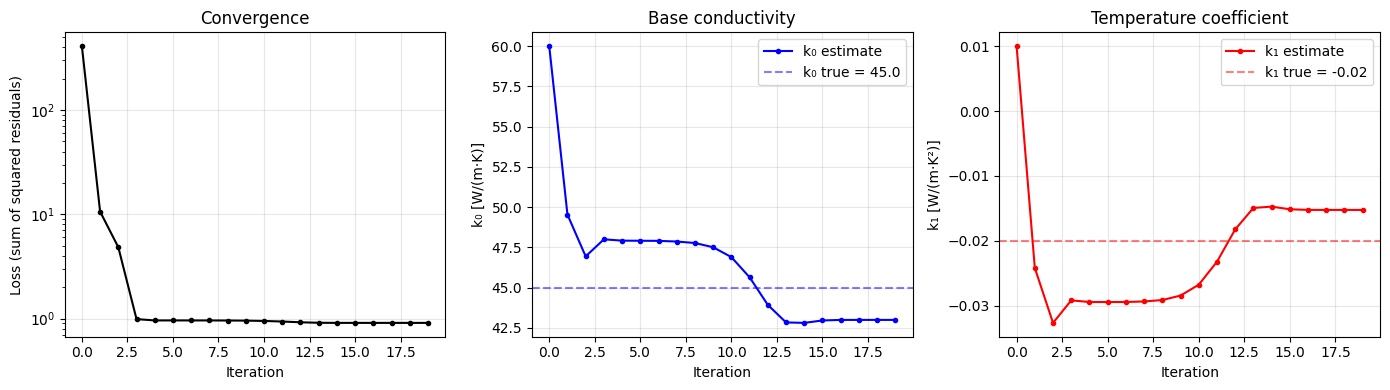

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss convergence
axes[0].semilogy(history["loss"], "k.-", linewidth=1.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss (sum of squared residuals)")
axes[0].set_title("Convergence")
axes[0].grid(True, alpha=0.3)

# k0 convergence
axes[1].plot(history["k0"], "b.-", linewidth=1.5, label="k₀ estimate")
axes[1].axhline(
    k0_true, color="b", linestyle="--", alpha=0.5, label=f"k₀ true = {k0_true}"
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("k₀ [W/(m·K)]")
axes[1].set_title("Base conductivity")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# k1 convergence
axes[2].plot(history["k1"], "r.-", linewidth=1.5, label="k₁ estimate")
axes[2].axhline(
    k1_true, color="r", linestyle="--", alpha=0.5, label=f"k₁ true = {k1_true}"
)
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("k₁ [W/(m·K²)]")
axes[2].set_title("Temperature coefficient")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Temperature fields: initial guess vs. optimized vs. ground truth

/var/folders/fk/g5ssrkz179z1mjmvqn1j3q1m0000gn/T/ipykernel_73719/639399457.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


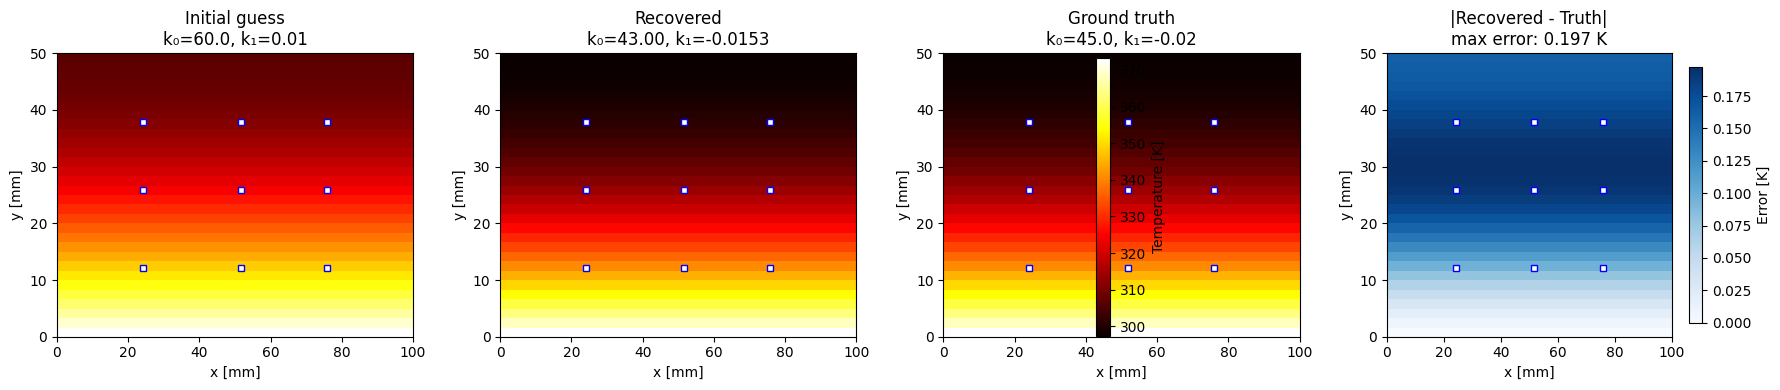

In [10]:
# Compute the initial-guess temperature field for comparison
T_init_field = np.asarray(solve(x0[0], x0[1])).reshape(ny, nx)

# Common color range
vmin = min(T_true.min(), T_opt.min(), T_init_field.min())
vmax = max(T_true.max(), T_opt.max(), T_init_field.max())

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
extent = [0, Lx * 1e3, 0, Ly * 1e3]

axes[0].imshow(
    T_init_field,
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title(f"Initial guess\nk₀={x0[0]}, k₁={x0[1]}")

axes[1].imshow(
    T_opt,
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title(f"Recovered\nk₀={k0_opt:.2f}, k₁={k1_opt:.4f}")

im2 = axes[2].imshow(
    T_true,
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)
axes[2].set_title(f"Ground truth\nk₀={k0_true}, k₁={k1_true}")

# Error field
error = np.abs(T_opt - T_true)
im3 = axes[3].imshow(error, origin="lower", cmap="Blues", extent=extent, aspect="auto")
axes[3].set_title(f"|Recovered - Truth|\nmax error: {error.max():.3f} K")

for ax in axes:
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    for ix, jy in sensor_coords:
        x_mm = ix / (nx - 1) * Lx * 1e3
        y_mm = jy / (ny - 1) * Ly * 1e3
        ax.plot(
            x_mm, y_mm, "ws", markersize=5, markeredgecolor="blue", markeredgewidth=1
        )

plt.colorbar(im2, ax=axes[:3].tolist(), label="Temperature [K]", shrink=0.9)
plt.colorbar(im3, ax=axes[3], label="Error [K]", shrink=0.9)
plt.tight_layout()
plt.show()

## Part 2: Thermal forensics — recovering a hidden heat signature (900 parameters)

A steel plate was subjected to an unmonitored heating event — say, a laser pulse
or a localized defect generating heat. Five seconds later, you measure temperatures
at 100 sensor locations. Can you reconstruct what the initial temperature
distribution looked like?

This is an ill-posed inverse problem: 900 unknowns (temperature at every grid cell)
from 100 noisy observations, through a nonlinear PDE. We add a small Tikhonov term
that penalizes departure from the ambient prior, which regularizes the problem; the
optimizer is otherwise the same `jax.value_and_grad` + L-BFGS-B as before — only the
parameter vector grows from 2 to 900. This is exactly where reverse-mode AD stops
being a nice-to-have:

| Method | Forward solves per iteration |
|--------|----------------------------:|
| Finite differences | 901 (N+1) |
| Reverse-mode AD | 2 (forward + reverse) |
| **Speedup** | **~450×** |

Finite differences would need 901 forward solves every iteration to assemble all
900 gradients; one reverse sweep returns them all for roughly the cost of two
forward passes. The Tikhonov term is just another addition to the JAX loss —
`jax.value_and_grad` differentiates it for free.

In [11]:
# --- Part 2 setup ---
# Shorter simulation: 5 seconds (we want residual structure in the initial field)
n_steps_p2 = 100
dt_p2 = 0.05

# Fixed material properties (known — we're recovering T_init, not k)
k0_p2 = 45.0
k1_p2 = -0.01

# Build coordinate arrays for the 30x30 grid
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)
X_flat, Y_flat = X.flatten(), Y.flatten()

# True initial temperature: two Gaussian hot spots on a warm background
T_init_true = (
    T_inf
    + 40.0 * np.exp(-((X_flat - 0.04) ** 2 + (Y_flat - 0.025) ** 2) / 0.015**2)
    + 25.0 * np.exp(-((X_flat - 0.08) ** 2 + (Y_flat - 0.035) ** 2) / 0.01**2)
)


def make_inputs_p2(T_init_field):
    """Inputs for the forensics problem; T_init_field is the differentiable unknown."""
    return {
        "T_init": jnp.asarray(T_init_field),
        "Q": jnp.asarray(Q),
        "nx": nx,
        "ny": ny,
        "n_steps": n_steps_p2,
        "k0": jnp.float64(k0_p2),
        "k1": jnp.float64(k1_p2),
        "rho": jnp.float64(rho),
        "cp": jnp.float64(cp),
        "h_conv": jnp.float64(h_conv),
        "T_inf": jnp.float64(T_inf),
        "T_hot": jnp.float64(T_hot),
        "Lx": jnp.float64(Lx),
        "Ly": jnp.float64(Ly),
        "dt": jnp.float64(dt_p2),
    }


def solve_p2(T_init_field):
    return apply_tesseract(enzyme_tess, make_inputs_p2(T_init_field))["T_final"]


# Run forward simulation with the true initial field
T_final_true_p2 = np.asarray(solve_p2(T_init_true))

# 10x10 sensor grid (100 sensors in the interior)
sensor_ix_p2 = np.linspace(3, nx - 4, 10, dtype=int)
sensor_jy_p2 = np.linspace(3, ny - 4, 10, dtype=int)
sensor_grid = np.array([(jy * nx + ix) for jy in sensor_jy_p2 for ix in sensor_ix_p2])
n_sensors_p2 = len(sensor_grid)

# Observed data: true final temperatures at sensors + noise
noise_std_p2 = 0.3  # K
T_obs_p2 = T_final_true_p2[sensor_grid] + rng.normal(0, noise_std_p2, n_sensors_p2)

print(f"Grid: {nx}x{ny} = {n} unknowns")
print(f"Sensors: {n_sensors_p2}")
print(f"Simulation: {n_steps_p2} steps x {dt_p2}s = {n_steps_p2 * dt_p2:.0f}s")
print(f"True T_init range: {T_init_true.min():.1f} — {T_init_true.max():.1f} K")

Grid: 30x30 = 900 unknowns
Sensors: 100
Simulation: 100 steps x 0.05s = 5s
True T_init range: 293.2 — 332.7 K


In [12]:
import time

T_obs_p2_jax = jnp.asarray(T_obs_p2)
sensor_grid_jax = jnp.asarray(sensor_grid)

# Tikhonov regularization weight: penalizes departure from the ambient prior,
# which stabilizes this ill-posed problem (900 unknowns, 100 observations).
alpha_reg = 0.001


def loss_fn_p2(T_init_vec):
    """Regularized sensor-misfit loss for the 900-element initial field. Pure JAX."""
    T_pred = solve_p2(T_init_vec)
    residuals = T_pred[sensor_grid_jax] - T_obs_p2_jax
    data_loss = 0.5 * jnp.sum(residuals**2)
    reg_loss = 0.5 * alpha_reg * jnp.sum((T_init_vec - T_inf) ** 2)
    return data_loss + reg_loss


value_and_grad_p2 = jax.jit(jax.value_and_grad(loss_fn_p2))

# warm up JIT
_ = value_and_grad_p2(jnp.asarray(T_init))


def scipy_objective_p2(T_init_vec):
    loss, grad = value_and_grad_p2(jnp.asarray(T_init_vec))
    return float(loss), np.asarray(grad, dtype=np.float64)


# Start from uniform ambient (the wrong answer)
T_init_guess = np.full(n, T_inf)
loss_history_p2 = []

iter_count = [0]
t_start = time.time()


def callback_p2(x):
    iter_count[0] += 1
    if iter_count[0] % 10 == 0:
        loss, _ = scipy_objective_p2(x)
        loss_history_p2.append(loss)
        elapsed = time.time() - t_start
        print(f"  iter {iter_count[0]:3d}: loss={loss:.4f}, elapsed={elapsed:.1f}s")


loss0_p2 = scipy_objective_p2(T_init_guess)[0]
loss_history_p2.append(loss0_p2)
print(f"Initial loss: {loss0_p2:.2f}")
print(f"Running L-BFGS-B with {n} parameters...")

result_p2 = minimize(
    fun=scipy_objective_p2,
    x0=T_init_guess,
    method="L-BFGS-B",
    jac=True,
    bounds=[(250.0, 450.0)] * n,
    callback=callback_p2,
    options={"maxiter": 200, "ftol": 1e-15, "gtol": 1e-10},
)

elapsed_total = time.time() - t_start
loss_final = scipy_objective_p2(result_p2.x)[0]
loss_history_p2.append(loss_final)
T_init_recovered = result_p2.x

print(f"\nOptimization finished: {result_p2.nit} iterations, {elapsed_total:.1f}s")
print(f"Loss: {loss0_p2:.2f} → {loss_final:.4f}")
print(f"T_init correlation: {np.corrcoef(T_init_true, T_init_recovered)[0, 1]:.4f}")
print("\nCost comparison per iteration:")
print(
    f"  Finite differences: {n + 1} forward solves = "
    f"~{(n + 1) * elapsed_total / result_p2.nfev:.1f}s"
)
print(
    f"  Reverse-mode AD:    2 solves (fwd+rev)   = "
    f"~{2 * elapsed_total / result_p2.nfev:.2f}s"
)

Initial loss: 4072.76
Running L-BFGS-B with 900 parameters...
  iter  10: loss=54.0890, elapsed=0.3s
  iter  20: loss=53.9501, elapsed=0.7s
  iter  30: loss=53.9492, elapsed=1.1s
  iter  40: loss=53.9492, elapsed=1.4s
  iter  50: loss=53.9492, elapsed=1.8s
  iter  60: loss=53.9492, elapsed=2.1s

Optimization finished: 65 iterations, 2.6s
Loss: 4072.76 → 53.9492
T_init correlation: 0.9799

Cost comparison per iteration:
  Finite differences: 901 forward solves = ~28.2s
  Reverse-mode AD:    2 solves (fwd+rev)   = ~0.06s


/var/folders/fk/g5ssrkz179z1mjmvqn1j3q1m0000gn/T/ipykernel_73719/182219165.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


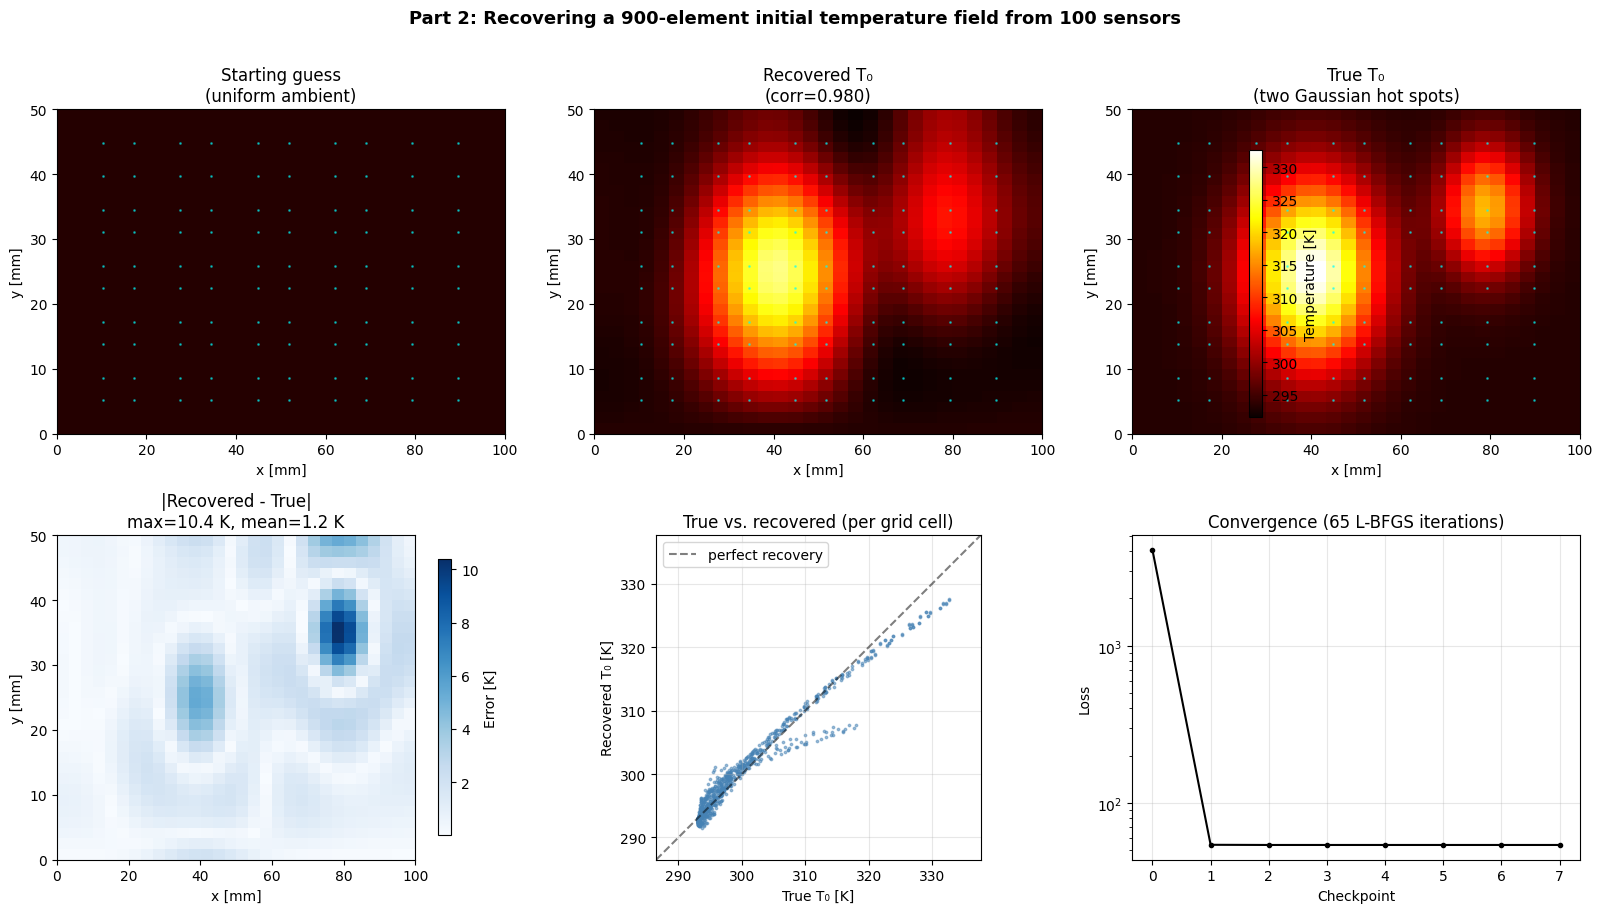

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

extent = [0, Lx * 1e3, 0, Ly * 1e3]

# --- Top row: initial temperature fields ---
vmin_init = min(T_init_true.min(), T_init_recovered.min(), T_inf)
vmax_init = max(T_init_true.max(), T_init_recovered.max())

axes[0, 0].imshow(
    T_init_guess.reshape(ny, nx),
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin_init,
    vmax=vmax_init,
)
axes[0, 0].set_title("Starting guess\n(uniform ambient)")

axes[0, 1].imshow(
    T_init_recovered.reshape(ny, nx),
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin_init,
    vmax=vmax_init,
)
axes[0, 1].set_title(
    f"Recovered T₀\n(corr={np.corrcoef(T_init_true, T_init_recovered)[0, 1]:.3f})"
)

im_true = axes[0, 2].imshow(
    T_init_true.reshape(ny, nx),
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin_init,
    vmax=vmax_init,
)
axes[0, 2].set_title("True T₀\n(two Gaussian hot spots)")

plt.colorbar(im_true, ax=axes[0, :].tolist(), label="Temperature [K]", shrink=0.85)

# Mark sensor locations on all top-row plots
for ax in axes[0, :]:
    for jy_idx in sensor_jy_p2:
        for ix_idx in sensor_ix_p2:
            x_mm = ix_idx / (nx - 1) * Lx * 1e3
            y_mm = jy_idx / (ny - 1) * Ly * 1e3
            ax.plot(x_mm, y_mm, ".", color="cyan", markersize=2, alpha=0.5)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")

# --- Bottom row: diagnostics ---
error_p2 = np.abs(T_init_recovered - T_init_true).reshape(ny, nx)
im_err = axes[1, 0].imshow(
    error_p2, origin="lower", cmap="Blues", extent=extent, aspect="auto"
)
axes[1, 0].set_title(
    f"|Recovered - True|\nmax={error_p2.max():.1f} K, mean={error_p2.mean():.1f} K"
)
axes[1, 0].set_xlabel("x [mm]")
axes[1, 0].set_ylabel("y [mm]")
plt.colorbar(im_err, ax=axes[1, 0], label="Error [K]", shrink=0.85)

axes[1, 1].scatter(T_init_true, T_init_recovered, s=3, alpha=0.5, c="steelblue")
lims = [vmin_init - 5, vmax_init + 5]
axes[1, 1].plot(lims, lims, "k--", alpha=0.5, label="perfect recovery")
axes[1, 1].set_xlim(lims)
axes[1, 1].set_ylim(lims)
axes[1, 1].set_xlabel("True T₀ [K]")
axes[1, 1].set_ylabel("Recovered T₀ [K]")
axes[1, 1].set_title("True vs. recovered (per grid cell)")
axes[1, 1].legend()
axes[1, 1].set_aspect("equal")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].semilogy(loss_history_p2, "k.-", linewidth=1.5)
axes[1, 2].set_xlabel("Checkpoint")
axes[1, 2].set_ylabel("Loss")
axes[1, 2].set_title(f"Convergence ({result_p2.nit} L-BFGS iterations)")
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(
    "Part 2: Recovering a 900-element initial temperature field from 100 sensors",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

## What just happened

Each `jax.value_and_grad` call above triggered this chain:

| Layer | Technology | Role |
|-------|-----------|------|
| Optimizer | SciPy L-BFGS-B | Quasi-Newton update loop |
| AD framework | JAX reverse-mode | Propagates cotangents |
| Tesseract bridge | `tesseract-jax` | Registers JAX primitive, dispatches HTTP calls |
| Transport | HTTP + JSON | Crosses the process/container boundary |
| AD engine | Enzyme (LLVM pass) | Generates the VJP from compiled Fortran IR |
| Solver | Fortran 90 | `thermal_2d_solve` |

The Fortran solver was never modified. Enzyme differentiated it from the compiled
LLVM IR, and Tesseract made it callable — and differentiable — from JAX. The
optimization code is identical for 2 parameters and for 900; only the size of the
parameter vector changed.

In [14]:
# Tear down the Tesseract to free resources.
enzyme_tess.teardown()